# Лабораторная работа: Многослойный персептрон
Краткая версия ноутбука: только решения заданий.

**Содержание:**
1. Линейная регрессия одним нейроном
2. Классификация точек на плоскости
3. Демонстрация переобучения

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt


In [2]:
def build_model(rate):
    # Строим модель в виде последовательно подключаемых слоев (промежуточные слои соединяются автоматом).
    model = tf.keras.models.Sequential()
    # В нашем случае в виде одного слоя из одного единственного нейрона:
    model.add(tf.keras.layers.Dense(units=1, # количество нейронов
    input_shape=(1,))) # размерность входов
    # Скомпилируем нашу модель в код, который исполнит TensorFlow. В качестве функции потерь, которую мы будем минимизировать, выберем среднеквадратическую ошибку
    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=rate),
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model
    

In [3]:
def train_model(model, feature, label, epochs, batch_size):
    history = model.fit(x=feature, y=label, batch_size=batch_size, epochs=epochs)
    # Сохраняем итоговые веса нейрона в отдельные переменные
    trained_weight = model.get_weights()[0]
    trained_bias = model.get_weights()[1]
    # Отдельно сохраним список эпох обучения
    epochs = history.epoch
    # Преобразуем данные к формату Pandas.DataFrame
    hist = pd.DataFrame(history.history)
    # Сохраним данные о среднеквадратической ошибке
    rmse = hist["root_mean_squared_error"]
    # ---------
    return trained_weight, trained_bias, epochs, rmse
    

In [4]:
def plot_the_model(trained_weight, trained_bias, feature, label):
    plt.xlabel("feature")
    plt.ylabel("label")
    # входные данные по оси x, выходные по оси y
    plt.scatter(feature, label)
    # Модель линейной регрессии будет представлена красной линией с началом в (x0, y0) и концом в (x1, y1).
    x0 = 0
    y0 = trained_bias[0]
    x1 = feature[-1]
    y1 = trained_bias[0] + (trained_weight[0][0] * x1)
    #print([x0, x1], [*y0, *y1[0]])
    plt.plot([x0, x1], [y0, y1], c='r')
    plt.show()
    

In [5]:
def plot_the_loss_curve(epochs, rmse):
    plt.figure()
    plt.xlabel("Epoch")
    plt.ylabel("Root Mean Squared Error")
    plt.plot(epochs, rmse, label="Loss")
    plt.legend()
    plt.ylim([rmse.min()*0.97, rmse.max()])
    plt.show()
    

Epoch 1/150


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - loss: 283.0226 - root_mean_squared_error: 16.8233
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 265.7532 - root_mean_squared_error: 16.3019
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 253.7478 - root_mean_squared_error: 15.9295
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 244.0004 - root_mean_squared_error: 15.6205
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 235.5684 - root_mean_squared_error: 15.3482
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 228.0173 - root_mean_squared_error: 15.1002
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 221.1060 - root_mean_squared_error: 14.8696
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 214.6850 - root_mean_squared_error: 14.6521
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 208.6546 - root_mean_squared_error: 14.4449
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 202.9447 - root_mean_squared_error

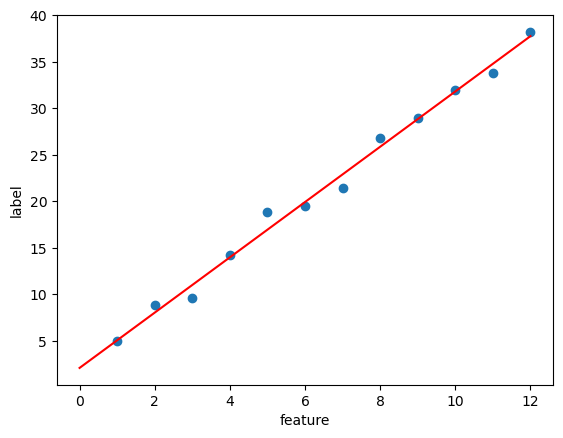

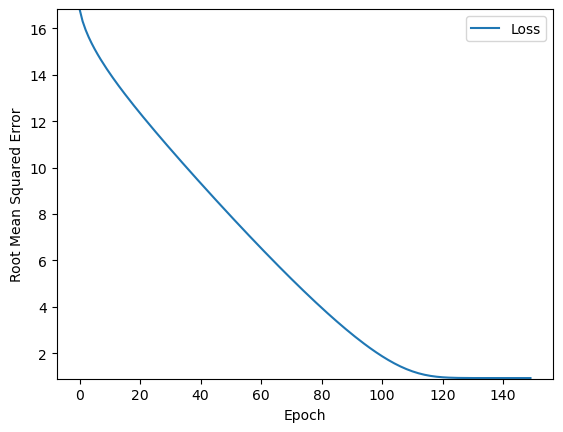

In [6]:
features = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0])
labels = np.array([5.0, 8.8, 9.6, 14.2, 18.8, 19.5, 21.4, 26.8, 28.9, 32.0, 33.8, 38.2])

learning_rate=0.02 # выберем малую скорость обучения
epochs=150 # возьмем небольшое число эпох для обучения
my_batch_size=12 # задействуем все обучающие примеры за одну эпоху обучения.

my_model = build_model(learning_rate)

trained_weight, trained_bias, epochs, rmse = train_model(my_model, features, labels, epochs, my_batch_size)

plot_the_model(trained_weight, trained_bias, features, labels)

plot_the_loss_curve(epochs, rmse)


## Классификация точек (Задания 3–4)
Используется MLP с `ReLU` + `Softmax` для разделения точек на классы.

Точка (0, 0): Зона 1, Знаки: [1.0, 1.0, 1.0, 1.0, 1.0]
Точка (0, 0.5): Зона 3, Знаки: [-1.0, 1.0, 1.0, 1.0, 1.0]
Точка (0.5, 0.2): Зона 3, Знаки: [1.0, 1.0, 1.0, 1.0, -1.0]
Точка (-0.5, 0.2): Зона 3, Знаки: [1.0, -1.0, 1.0, 1.0, 1.0]
Точка (-0.2, -0.5): Зона 3, Знаки: [1.0, 1.0, -1.0, 1.0, 1.0]
Точка (0.2, -0.5): Зона 3, Знаки: [1.0, 1.0, 1.0, -1.0, 1.0]
Точка (0.5, 0.5): Зона 2, Знаки: [-1.0, 1.0, 1.0, 1.0, -1.0]
Точка (-0.5, 0.5): Зона 2, Знаки: [-1.0, -1.0, 1.0, 1.0, 1.0]
Точка (1, -0.5): Зона 2, Знаки: [1.0, 1.0, 1.0, -1.0, -1.0]
Точка (0, -1): Зона 2, Знаки: [1.0, 1.0, -1.0, -1.0, 1.0]
Точка (-1, -0.5): Зона 2, Знаки: [1.0, -1.0, -1.0, 1.0, 1.0]
Точка (1, -1.4): Зона 4, Знаки: [1.0, 1.0, -1.0, -1.0, -1.0]
Точка (-1, -1.4): Зона 4, Знаки: [1.0, -1.0, -1.0, -1.0, 1.0]
Точка (-1.4, 0.5): Зона 4, Знаки: [-1.0, -1.0, -1.0, 1.0, 1.0]
Точка (1.4, 0.5): Зона 4, Знаки: [-1.0, 1.0, 1.0, -1.0, -1.0]
Точка (0, 1.4): Зона 4, Знаки: [-1.0, -1.0, 1.0, 1.0, -1.0]


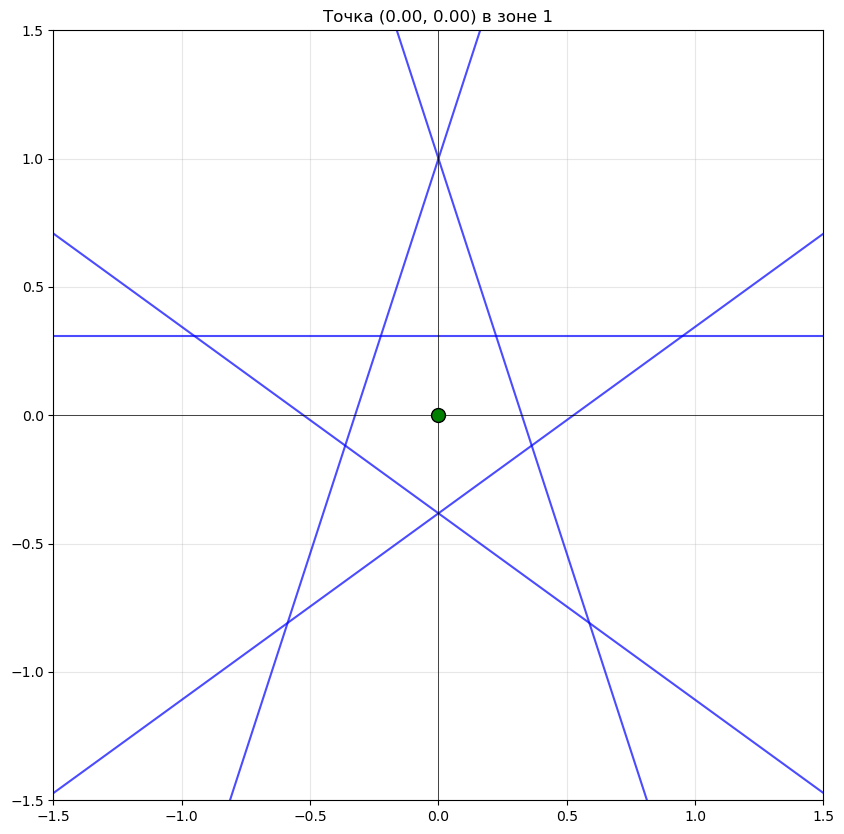

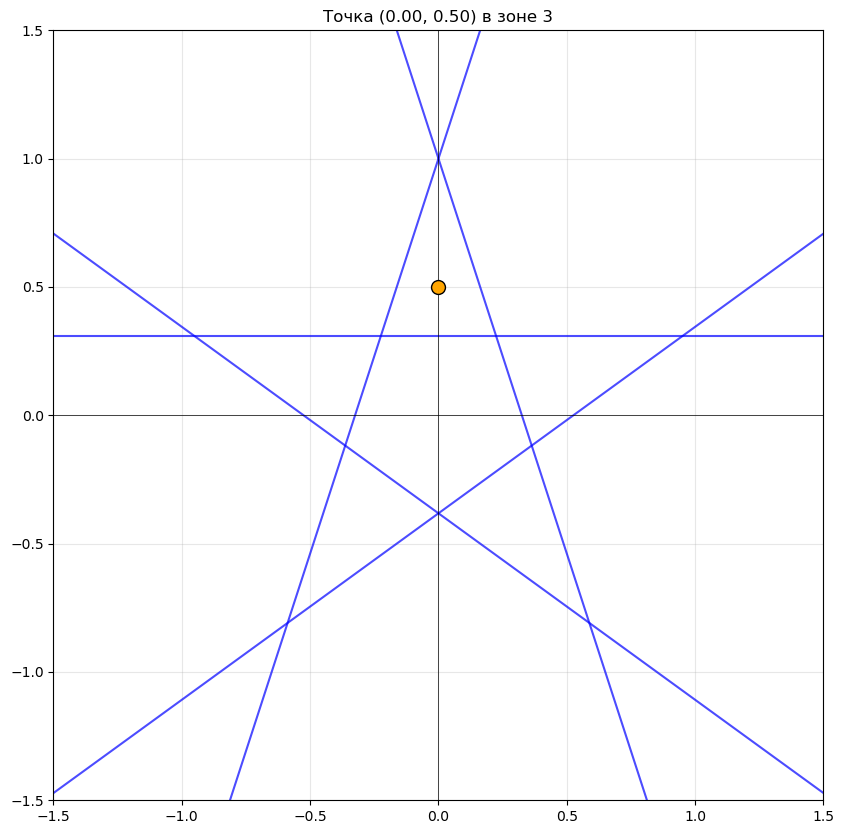

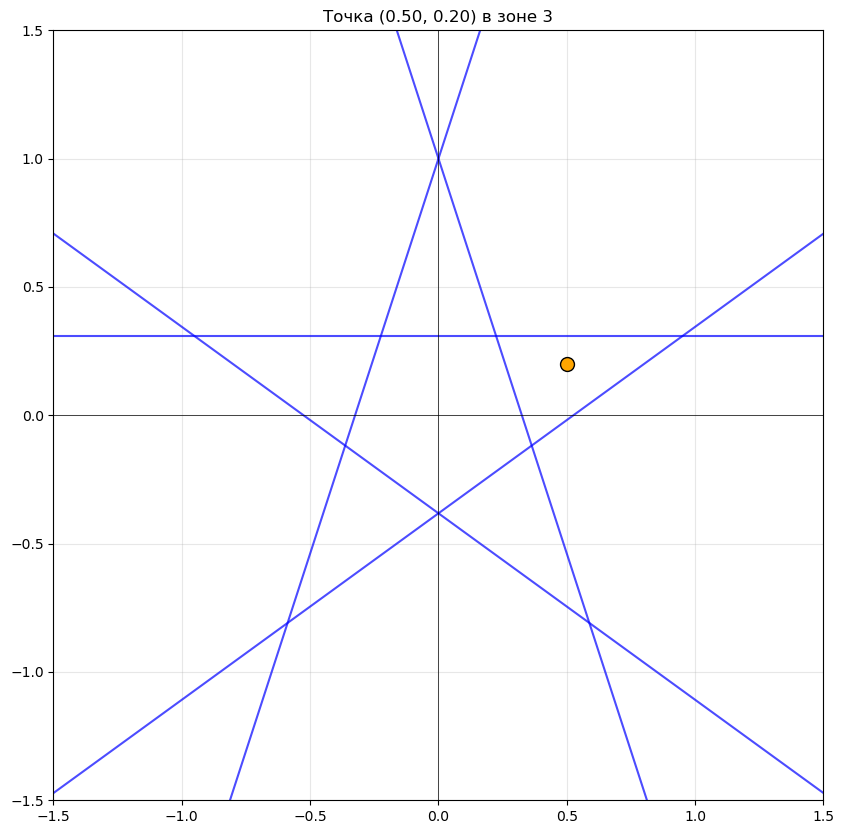

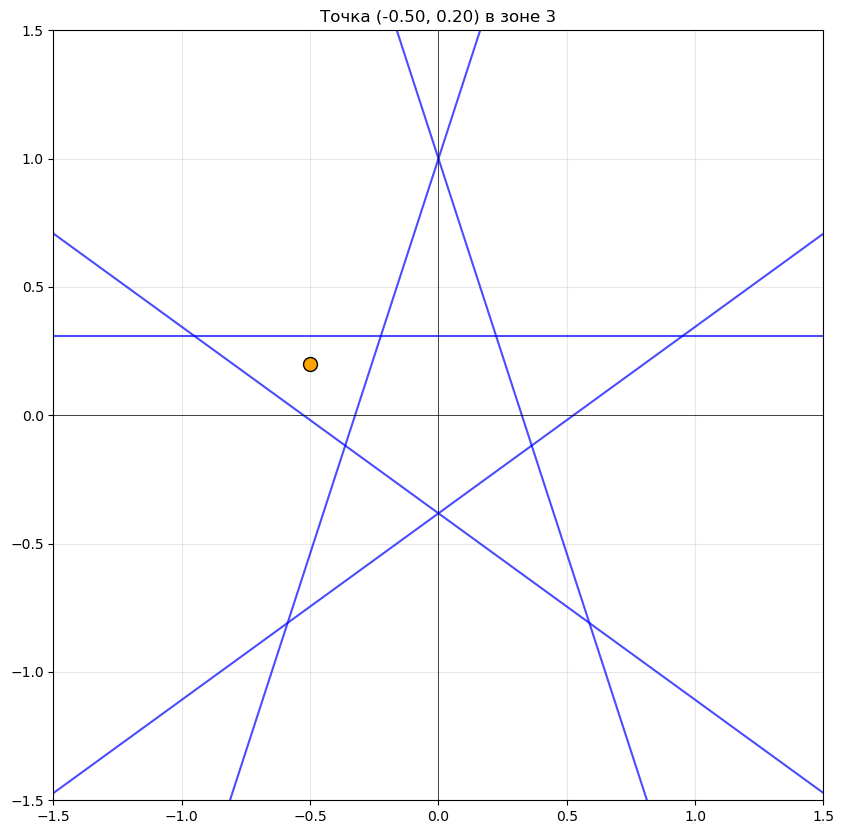

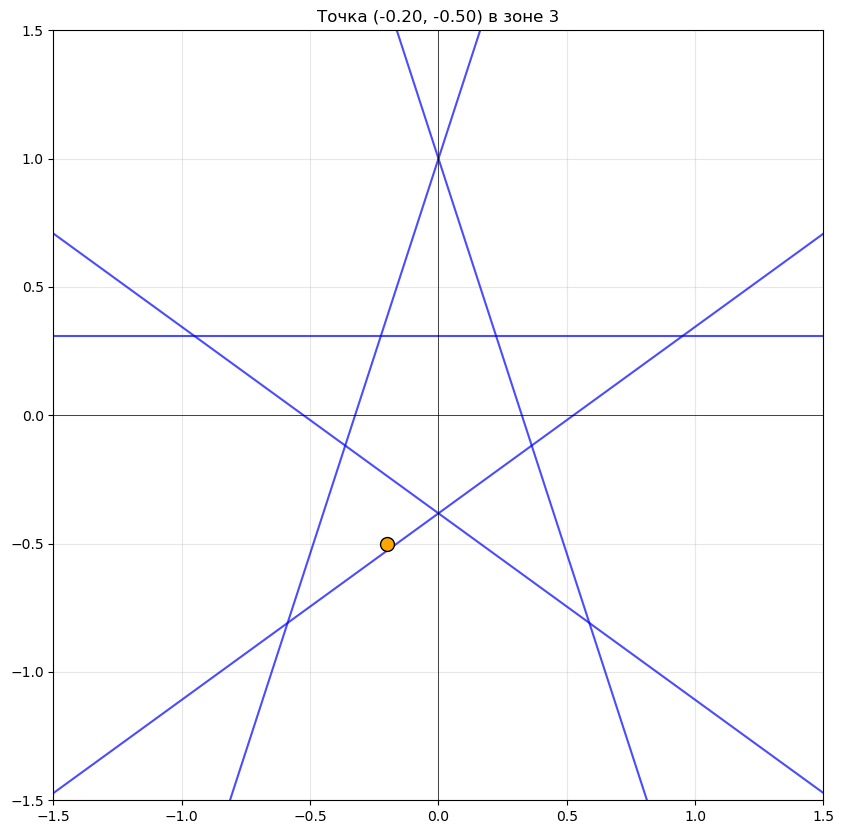

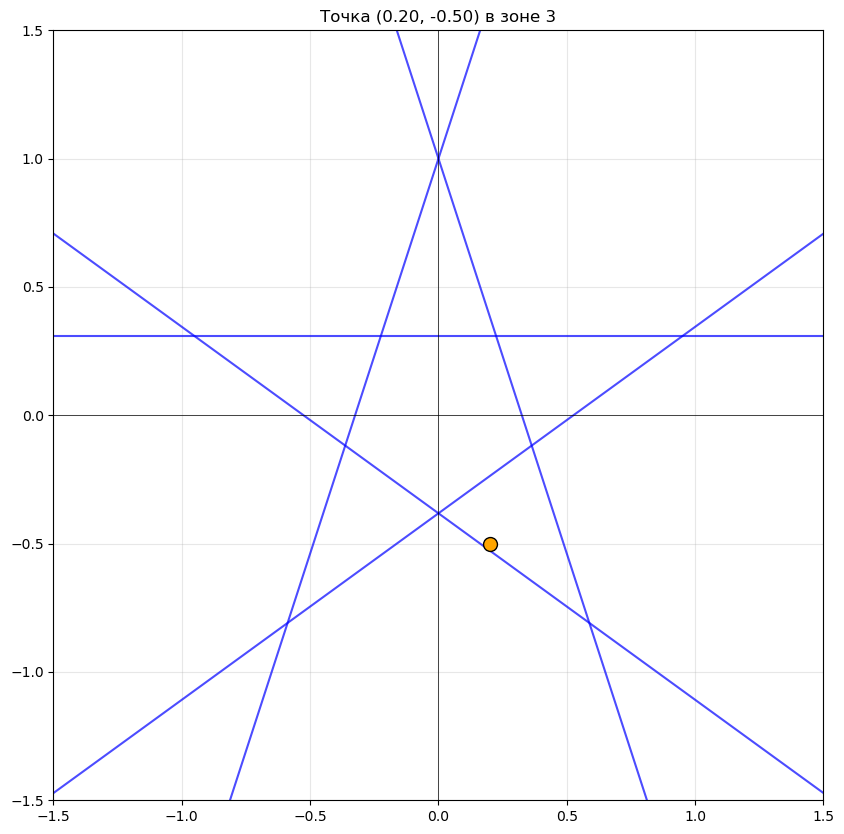

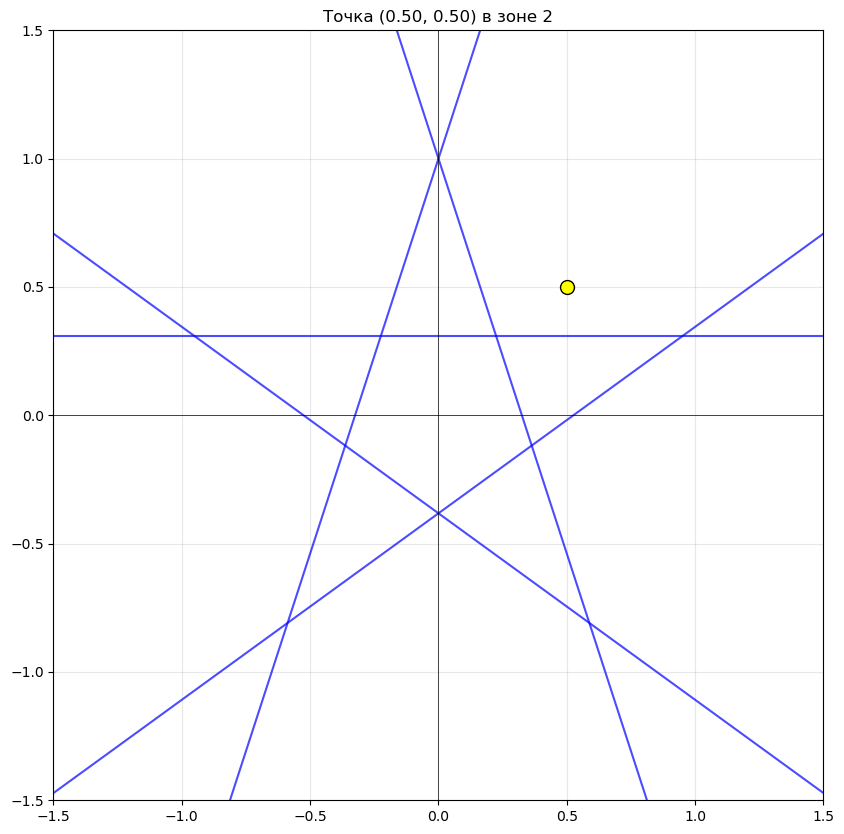

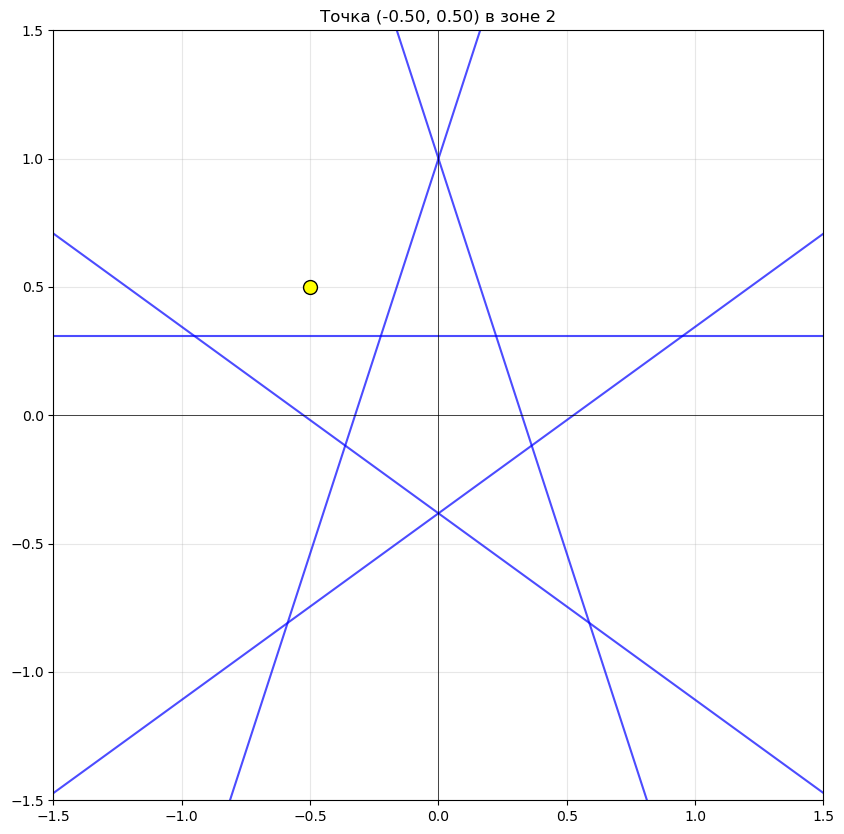

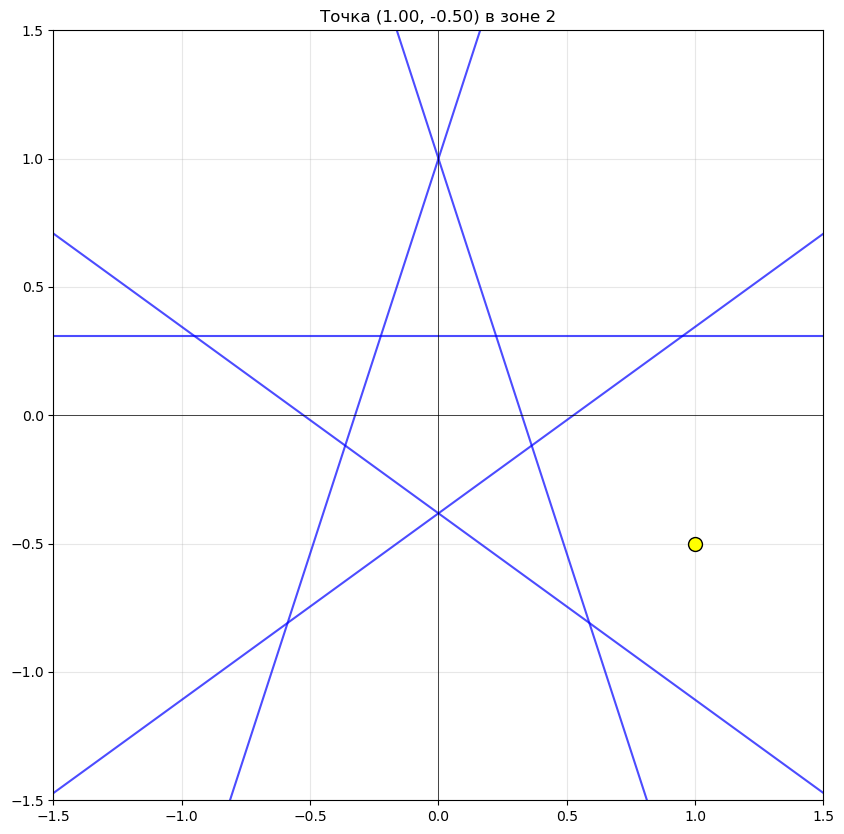

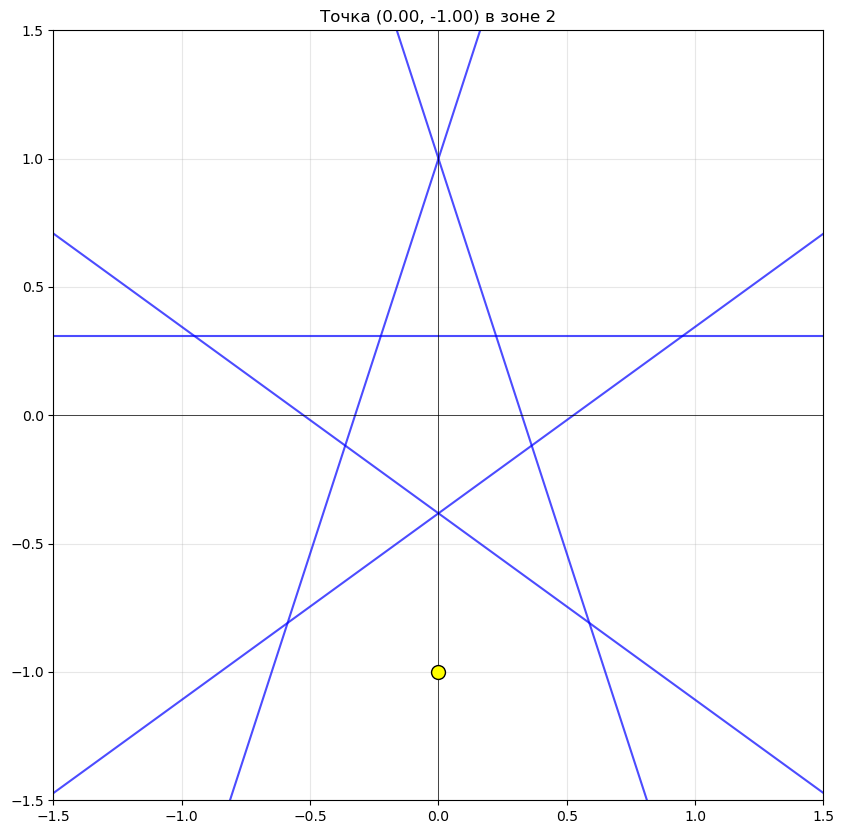

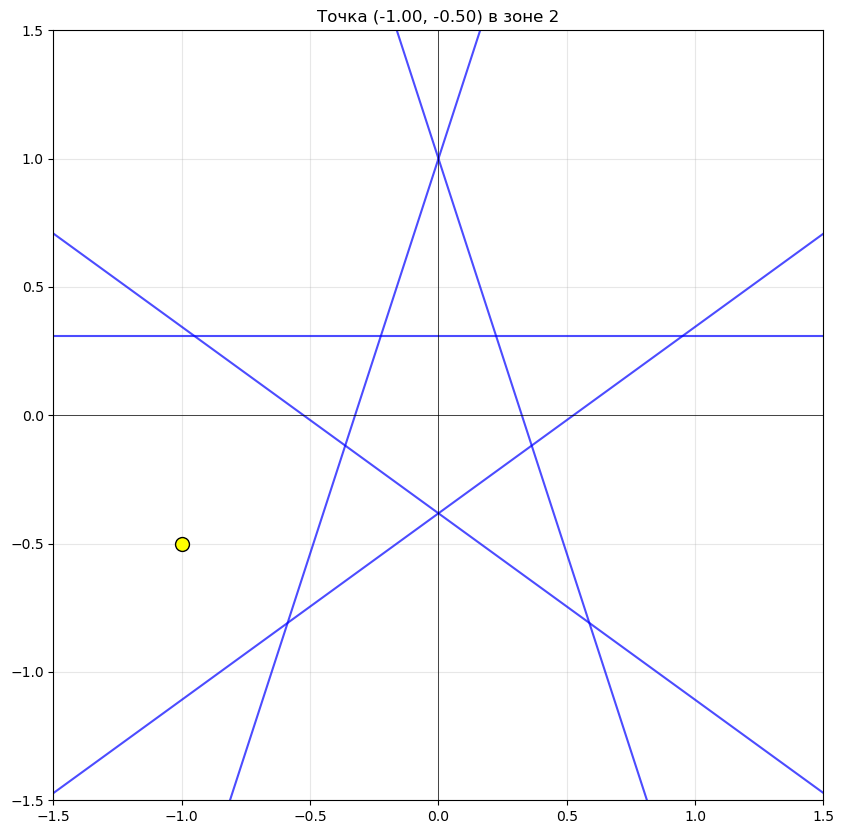

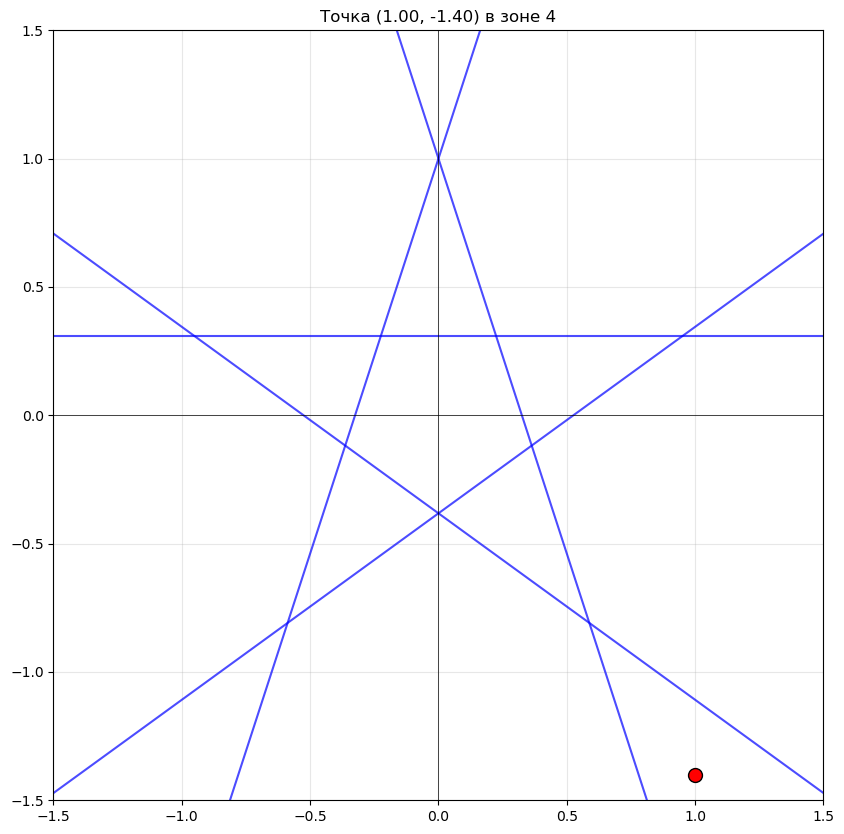

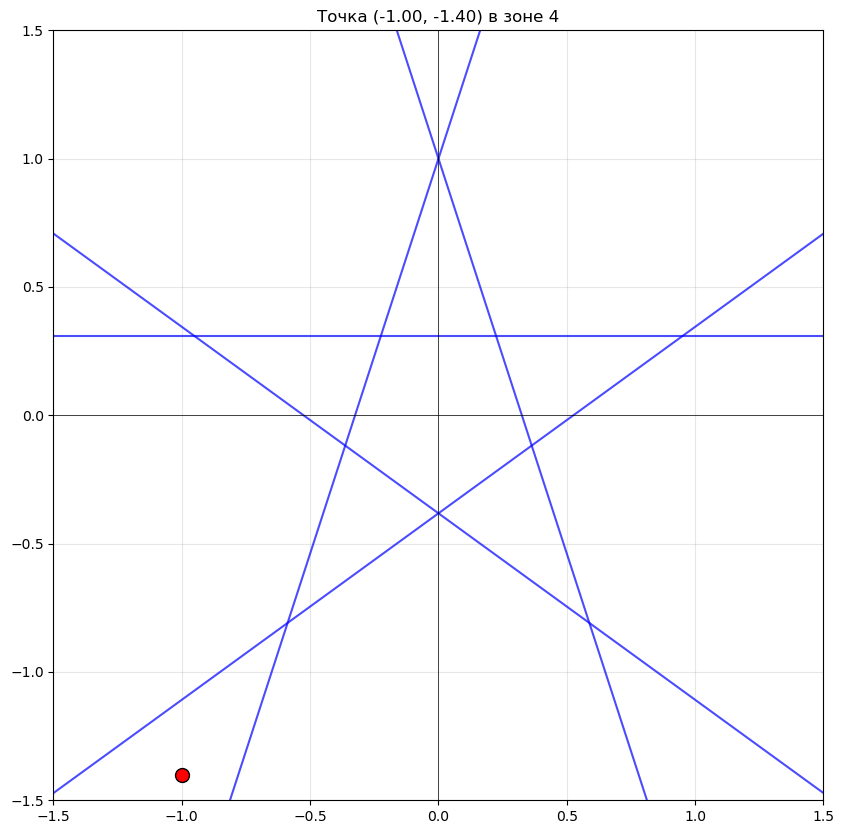

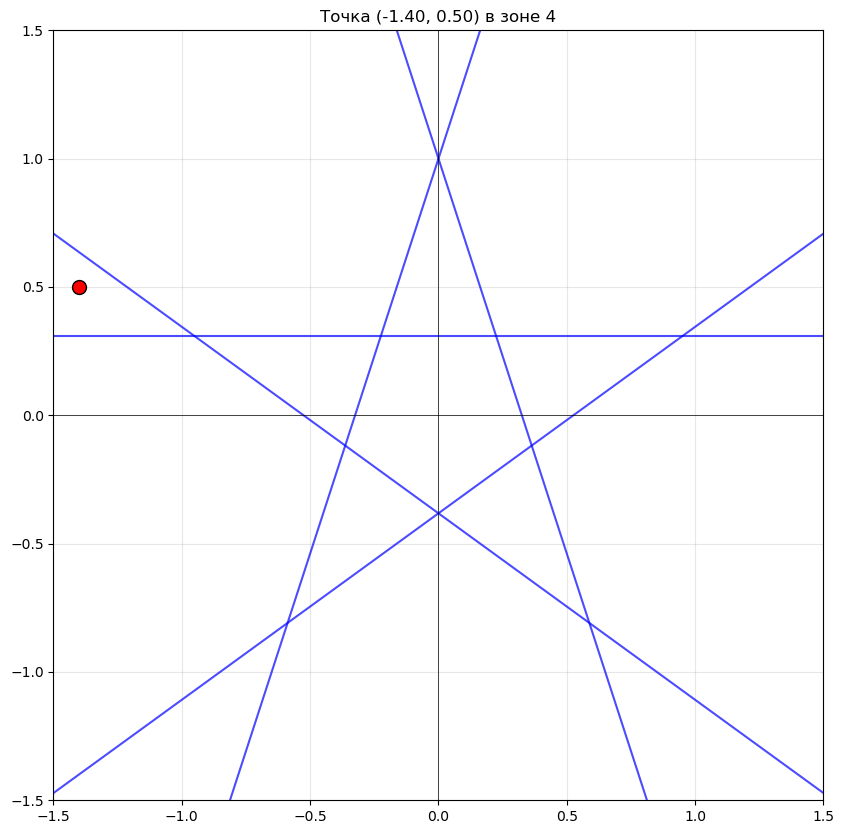

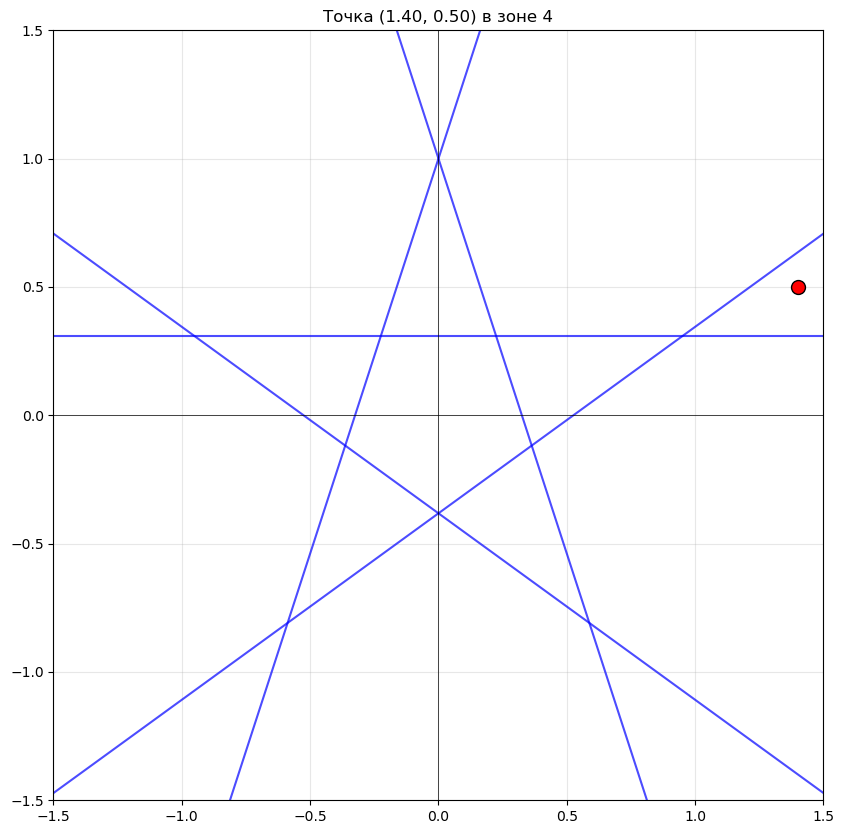

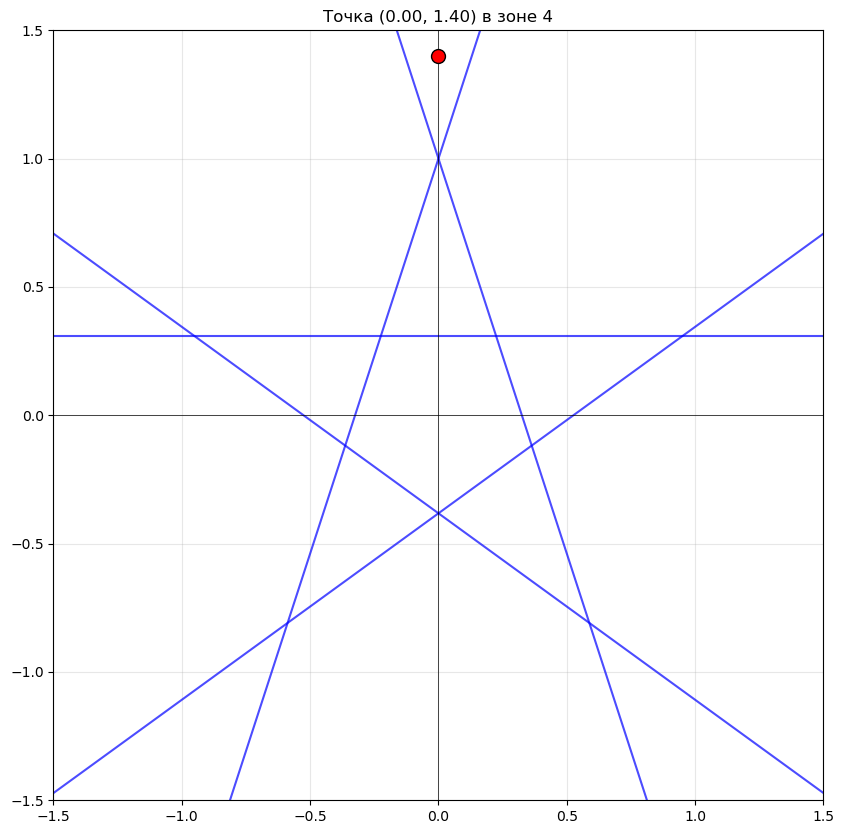

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def region_from_signs(signs):
    # Если точка лежит ровно на линии
    if 0 in signs:
        return 1
    
    pos = sum(1 for s in signs if s > 0)
    neg = sum(1 for s in signs if s < 0)
    
    # Центр звезды (внутренняя пентаграмма)
    if pos == 2 and neg == 3:
        return 4
    
    # Внутренний пояс (между центром и лучами)
    elif pos == 3 and neg == 2:
        return 2
    
    # Внешний пояс (лучи звезды)
    elif (pos == 4 and neg == 1) or (pos == 1 and neg == 4):
        return 3
    
    # Вне звезды
    else:
        return 1

def draw_five_pointed_star_with_point(x_point, y_point):
    # Правильные уравнения для 5-конечной звезды
    # Коэффициенты для линий, образующих звезду
    lines = [
        (np.tan(np.radians(18)), 1),        # Правая верхняя
        (np.tan(np.radians(54)), -np.sin(np.radians(72))),  # Правая нижняя
        (0, -np.cos(np.radians(36))),       # Центральная горизонтальная
        (-np.tan(np.radians(54)), -np.sin(np.radians(72))), # Левая нижняя
        (-np.tan(np.radians(18)), 1)        # Левая верхняя
    ]
    
    # Альтернативный подход - используем полярные координаты
    angles = [18, 90, 162, 234, 306]  # Углы для вершин звезды
    
    # Рисуем линии
    x = np.linspace(-2, 2, 500)
    plt.figure(figsize=(10, 10))
    
    for i in range(5):
        angle1 = np.radians(angles[i])
        angle2 = np.radians(angles[(i + 2) % 5])
        
        # Координаты двух вершин для линии
        x1, y1 = np.cos(angle1), np.sin(angle1)
        x2, y2 = np.cos(angle2), np.sin(angle2)
        
        # Уравнение линии через две точки
        if x2 != x1:
            m = (y2 - y1) / (x2 - x1)
            b = y1 - m * x1
            y_line = m * x + b
            plt.plot(x, y_line, 'b-', alpha=0.7)
        else:
            plt.axvline(x=x1, color='b', alpha=0.7)
    
    # Определяем знаки для точки относительно всех линий
    signs = []
    for i in range(5):
        angle1 = np.radians(angles[i])
        angle2 = np.radians(angles[(i + 2) % 5])
        
        x1, y1 = np.cos(angle1), np.sin(angle1)
        x2, y2 = np.cos(angle2), np.sin(angle2)
        
        # Векторное произведение для определения положения точки
        # относительно линии (x1,y1) -> (x2,y2)
        cross_product = (x2 - x1) * (y_point - y1) - (y2 - y1) * (x_point - x1)
        signs.append(np.sign(cross_product))
    
    # Определяем зону
    region = region_from_signs(signs)
    
    # Цвета для зон
    colors = {
        1: "green",   # центр
        2: "yellow",  # внутренний пояс
        3: "orange",  # внешний пояс (лучи)
        4: "red"      # снаружи
    }
    
    # Рисуем точку
    plt.scatter(x_point, y_point, color=colors[region], s=100, zorder=5, edgecolors='black')
    
    # Оси и настройки
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    
    plt.title(f"Точка ({x_point:.2f}, {y_point:.2f}) в зоне {region}")
    plt.show()
    
    return region, signs

# Тестируем различные точки
test_points = [
    (0, 0), 
    (0, 0.5),
    (0.5, 0.2),
    (-0.5, 0.2),
    (-0.2, -0.5),
    (0.2, -0.5),
    (0.5, 0.5),  
    (-0.5, 0.5),  
    (1, -0.5), 
    (0, -1),
    (-1, -0.5),  
    (1, -1.4),
    (-1, -1.4),
    (-1.4, 0.5),
    (1.4, 0.5),
    (0, 1.4)
]

for x0, y0 in test_points:
    region, signs = draw_five_pointed_star_with_point(x0, y0)
    print(f"Точка ({x0}, {y0}): Зона {region}, Знаки: {signs}")


## Переобучение (Задание 5)
Увеличено число нейронов и эпох, добавлена валидация `validation_split=0.2`.

 ЗАДАНИЕ 4: Базовая модель с минимальным числом нейронов 
Обучение базовой модели завершено


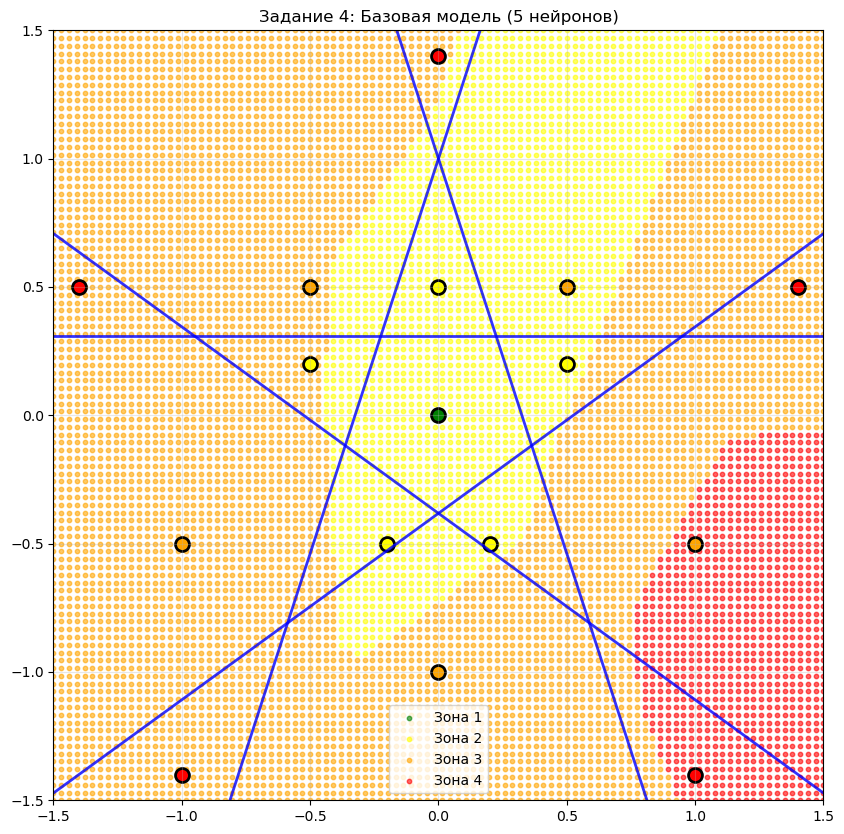

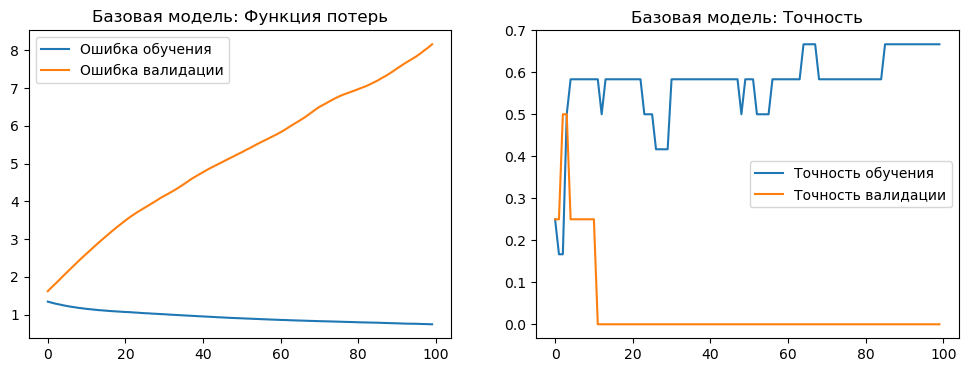


 ЗАДАНИЕ 5: Модель с увеличенным числом нейронов (переобучение) 
Обучение расширенной модели завершено


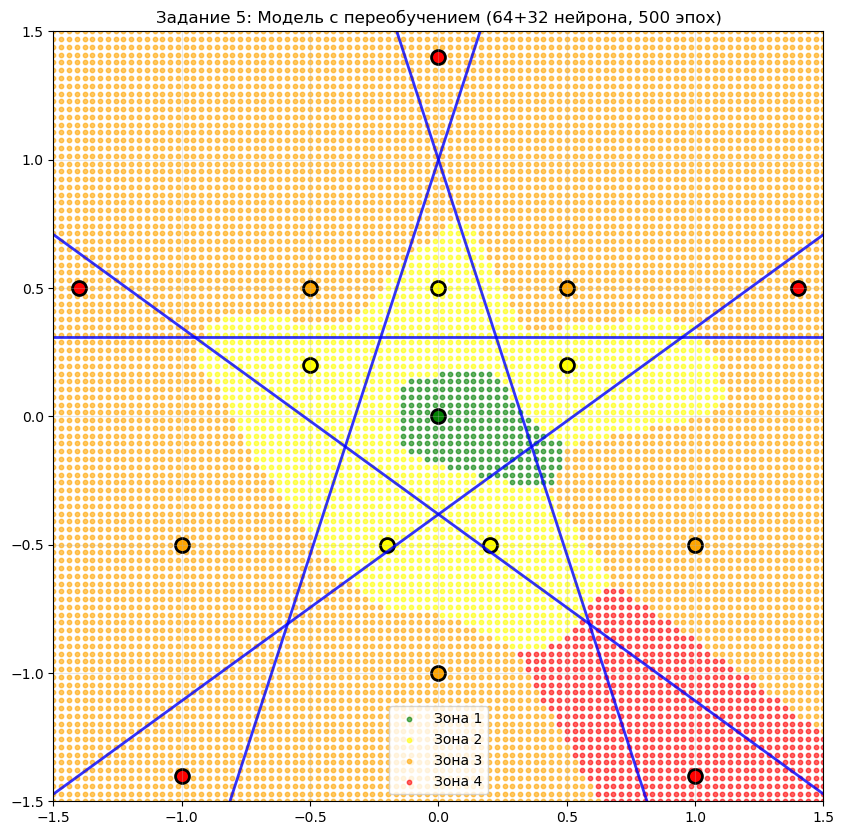

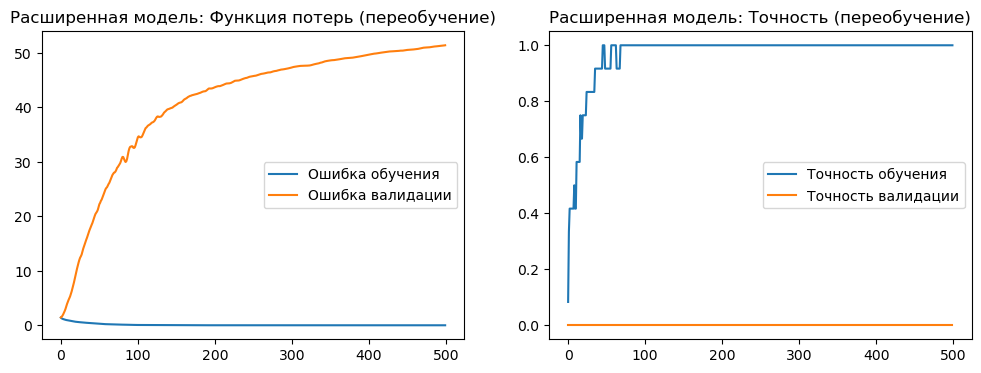


Проверка предсказаний на новых точках:
Точка -> Базовая модель | Расширенная модель
[0.3 0.3] -> Зона 2 | Зона 2
[-0.3 -0.3] -> Зона 2 | Зона 2
[0.8 0.1] -> Зона 3 | Зона 2
[-0.8  0.1] -> Зона 3 | Зона 2
[ 1.2 -0.8] -> Зона 4 | Зона 3
[-1.2 -0.8] -> Зона 3 | Зона 3

Сравнение моделей:
Базовая модель - Точность на обучающих данных: 0.500
Расширенная модель - Точность на обучающих данных: 0.750

Признаки переобучения в расширенной модели:
Ошибка обучения: 0.0003, Ошибка валидации: 51.3881
Точность обучения: 1.0000, Точность валидации: 0.0000
Разница в ошибке: 51.3878 (чем больше, тем сильнее переобучение)


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def region_from_signs(signs):
    # Если точка лежит ровно на линии
    if 0 in signs:
        return 1
    
    pos = sum(1 for s in signs if s > 0)
    neg = sum(1 for s in signs if s < 0)
    
    # Центр звезды (внутренняя пентаграмма)
    if pos == 2 and neg == 3:
        return 4
    
    # Внутренний пояс (между центром и лучами)
    elif pos == 3 and neg == 2:
        return 2
    
    # Внешний пояс (лучи звезды)
    elif (pos == 4 and neg == 1) or (pos == 1 and neg == 4):
        return 3
    
    # Вне звезды
    else:
        return 1

def draw_five_pointed_star_with_point(x_point, y_point):
    # Альтернативный подход - используем полярные координаты
    angles = [18, 90, 162, 234, 306]  # Углы для вершин звезды
    
    # Рисуем линии
    x = np.linspace(-2, 2, 500)
    plt.figure(figsize=(10, 10))
    
    for i in range(5):
        angle1 = np.radians(angles[i])
        angle2 = np.radians(angles[(i + 2) % 5])
        
        # Координаты двух вершин для линии
        x1, y1 = np.cos(angle1), np.sin(angle1)
        x2, y2 = np.cos(angle2), np.sin(angle2)
        
        # Уравнение линии через две точки
        if x2 != x1:
            m = (y2 - y1) / (x2 - x1)
            b = y1 - m * x1
            y_line = m * x + b
            plt.plot(x, y_line, 'b-', alpha=0.7)
        else:
            plt.axvline(x=x1, color='b', alpha=0.7)
    
    # Определяем знаки для точки относительно всех линий
    signs = []
    for i in range(5):
        angle1 = np.radians(angles[i])
        angle2 = np.radians(angles[(i + 2) % 5])
        
        x1, y1 = np.cos(angle1), np.sin(angle1)
        x2, y2 = np.cos(angle2), np.sin(angle2)
        
        # Векторное произведение для определения положения точки
        # относительно линии (x1,y1) -> (x2,y2)
        cross_product = (x2 - x1) * (y_point - y1) - (y2 - y1) * (x_point - x1)
        signs.append(np.sign(cross_product))
    
    # Определяем зону
    region = region_from_signs(signs)
    
    # Цвета для зон
    colors = {
        1: "green",   # центр
        2: "yellow",  # внутренний пояс
        3: "orange",  # внешний пояс (лучи)
        4: "red"      # снаружи
    }
    
    # Рисуем точку
    plt.scatter(x_point, y_point, color=colors[region], s=100, zorder=5, edgecolors='black')
    
    # Оси и настройки
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    
    plt.title(f"Точка ({x_point:.2f}, {y_point:.2f}) в зоне {region}")
    plt.show()
    
    return region, signs

# Подготовка данных для нейронной сети
points = np.array([
    [0, 0], 
    [0, 0.5],
    [0.5, 0.2],
    [-0.5, 0.2],
    [-0.2, -0.5],
    [0.2, -0.5],
    [0.5, 0.5],  
    [-0.5, 0.5],  
    [1, -0.5], 
    [0, -1],
    [-1, -0.5],  
    [1, -1.4],
    [-1, -1.4],
    [-1.4, 0.5],
    [1.4, 0.5],
    [0, 1.4]
])

# Метки в формате one-hot encoding для 4 классов (зоны 1-4)
# Индексы: 0=зона1, 1=зона2, 2=зона3, 3=зона4
labels = np.array([
    [1, 0, 0, 0],  # зона 1
    [0, 1, 0, 0],  # зона 2  
    [0, 1, 0, 0],  # зона 2
    [0, 1, 0, 0],  # зона 2
    [0, 1, 0, 0],  # зона 2
    [0, 1, 0, 0],  # зона 2
    [0, 0, 1, 0],  # зона 3
    [0, 0, 1, 0],  # зона 3
    [0, 0, 1, 0],  # зона 3
    [0, 0, 1, 0],  # зона 3
    [0, 0, 1, 0],  # зона 3
    [0, 0, 0, 1],  # зона 4
    [0, 0, 0, 1],  # зона 4
    [0, 0, 0, 1],  # зона 4
    [0, 0, 0, 1],  # зона 4
    [0, 0, 0, 1]   # зона 4
])

print(" ЗАДАНИЕ 4: Базовая модель с минимальным числом нейронов ")

# Задание 4: Минимальное число нейронов = 5 (по числу линий звезды)
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.Input(shape=(2,)))  # вход: 2 координаты (x, y)
model1.add(tf.keras.layers.Dense(5, activation='relu'))  # минимальное число нейронов = 5 линий
model1.add(tf.keras.layers.Dense(4, activation='softmax'))  # выход: 4 класса

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

# Обучение базовой модели
history1 = model1.fit(
    x=points, 
    y=labels, 
    batch_size=8, 
    epochs=100,
    validation_split=0.2,
    verbose=0
)

print("Обучение базовой модели завершено")

# Визуализация предсказаний для произвольных точек
def visualize_predictions(model, title, points_range=(-1.5, 1.5), resolution=100):
    # Создаем сетку точек для предсказания
    x = np.linspace(points_range[0], points_range[1], resolution)
    y = np.linspace(points_range[0], points_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    # Предсказания для всех точек сетки
    grid_points = np.c_[X.ravel(), Y.ravel()]
    predictions = model.predict(grid_points, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Цвета для классов
    colors = ['green', 'yellow', 'orange', 'red']
    
    # Визуализация
    plt.figure(figsize=(12, 10))
    
    # Рисуем предсказания
    for class_idx in range(4):
        mask = predicted_classes == class_idx
        plt.scatter(grid_points[mask, 0], grid_points[mask, 1], 
                   c=colors[class_idx], alpha=0.6, s=10, 
                   label=f'Зона {class_idx + 1}')
    
    # Рисуем исходные точки обучения
    true_classes = np.argmax(labels, axis=1)
    for class_idx in range(4):
        mask = true_classes == class_idx
        plt.scatter(points[mask, 0], points[mask, 1], 
                   c=colors[class_idx], edgecolors='black', 
                   s=100, marker='o', linewidth=2)
    
    # Рисуем линии звезды (упрощенно)
    angles = [18, 90, 162, 234, 306]
    for i in range(5):
        angle1 = np.radians(angles[i])
        angle2 = np.radians(angles[(i + 2) % 5])
        x1, y1 = np.cos(angle1), np.sin(angle1)
        x2, y2 = np.cos(angle2), np.sin(angle2)
        
        if x2 != x1:
            m = (y2 - y1) / (x2 - x1)
            b = y1 - m * x1
            x_line = np.array([-2, 2])
            y_line = m * x_line + b
            plt.plot(x_line, y_line, 'b-', linewidth=2, alpha=0.8)
    
    plt.xlim(points_range)
    plt.ylim(points_range)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация для базовой модели
visualize_predictions(model1, "Задание 4: Базовая модель (5 нейронов)")

# Кривые обучения для базовой модели
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Ошибка обучения')
plt.plot(history1.history['val_loss'], label='Ошибка валидации')
plt.title('Базовая модель: Функция потерь')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Точность обучения')
plt.plot(history1.history['val_accuracy'], label='Точность валидации')
plt.title('Базовая модель: Точность')
plt.legend()
plt.show()

print("\n ЗАДАНИЕ 5: Модель с увеличенным числом нейронов (переобучение) ")

# Задание 5: Увеличиваем число нейронов в несколько раз
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.Input(shape=(2,)))  # вход: 2 координаты (x, y)
model2.add(tf.keras.layers.Dense(64, activation='relu'))  # увеличенное число нейронов
model2.add(tf.keras.layers.Dense(32, activation='relu'))  # дополнительный слой
model2.add(tf.keras.layers.Dense(4, activation='softmax'))  # выход: 4 класса

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

# Обучение с большим числом эпох для демонстрации переобучения
history2 = model2.fit(
    x=points, 
    y=labels, 
    batch_size=8, 
    epochs=500,  # увеличенное число эпох
    validation_split=0.2,
    verbose=0
)

print("Обучение расширенной модели завершено")

# Визуализация для модели с переобучением
visualize_predictions(model2, "Задание 5: Модель с переобучением (64+32 нейрона, 500 эпох)")

# Кривые обучения для демонстрации переобучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Ошибка обучения')
plt.plot(history2.history['val_loss'], label='Ошибка валидации')
plt.title('Расширенная модель: Функция потерь (переобучение)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Точность обучения')
plt.plot(history2.history['val_accuracy'], label='Точность валидации')
plt.title('Расширенная модель: Точность (переобучение)')
plt.legend()
plt.show()

# Проверка предсказаний на тестовых точках
test_points = np.array([
    [0.3, 0.3],   # должна быть зона 2
    [-0.3, -0.3], # должна быть зона 2  
    [0.8, 0.1],   # должна быть зона 3
    [-0.8, 0.1],  # должна быть зона 3
    [1.2, -0.8],  # должна быть зона 4
    [-1.2, -0.8]  # должна быть зона 4
])

print("\nПроверка предсказаний на новых точках:")
print("Точка -> Базовая модель | Расширенная модель")

for i, point in enumerate(test_points):
    # Предсказание базовой модели
    pred1 = model1.predict(point.reshape(1, -1), verbose=0)
    class1 = np.argmax(pred1) + 1
    
    # Предсказание расширенной модели
    pred2 = model2.predict(point.reshape(1, -1), verbose=0)
    class2 = np.argmax(pred2) + 1
    
    print(f"{point} -> Зона {class1} | Зона {class2}")

# Сравнение точности моделей
train_loss1, train_acc1 = model1.evaluate(points, labels, verbose=0)
train_loss2, train_acc2 = model2.evaluate(points, labels, verbose=0)

print(f"\nСравнение моделей:")
print(f"Базовая модель - Точность на обучающих данных: {train_acc1:.3f}")
print(f"Расширенная модель - Точность на обучающих данных: {train_acc2:.3f}")

# Анализ переобучения
final_train_loss = history2.history['loss'][-1]
final_val_loss = history2.history['val_loss'][-1]
final_train_acc = history2.history['accuracy'][-1]
final_val_acc = history2.history['val_accuracy'][-1]

print(f"\nПризнаки переобучения в расширенной модели:")
print(f"Ошибка обучения: {final_train_loss:.4f}, Ошибка валидации: {final_val_loss:.4f}")
print(f"Точность обучения: {final_train_acc:.4f}, Точность валидации: {final_val_acc:.4f}")
print(f"Разница в ошибке: {abs(final_val_loss - final_train_loss):.4f} (чем больше, тем сильнее переобучение)")